In [1]:
# AI-Based Household Electricity Consumption Prediction Using Machine Learning


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("C:/Users/Nathan/Documents/ElectricityConsumption/data/tz_electricity_consumption.csv")

df.head(15)

,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,num_televisions,has_air_conditioner,num_fans,has_electric_water_heater,num_lighting_points,has_electric_cooker,num_smartphones_charged,has_washing_machine,avg_monthly_temp_c,monthly_consumption_kwh
0,TZ-HH-000001,Morogoro,Rural,2022,10,Cool Dry,3.0,4,Swahili House (Shared),Upper-Middle,...,2,0,0.0,1,13,0,6,0,23.8,70.1
1,TZ-HH-000002,Arusha,Rural,2024,5,Long Rains,2.0,2,Swahili House (Shared),Low,...,1,0,2.0,0,4,0,2,0,21.3,54.6
2,TZ-HH-000003,Zanzibar Urban/West,Urban,2024,11,Short Rains,6.0,4,Swahili House (Shared),Lower-Middle,...,1,0,1.0,0,10,0,7,0,29.0,83.5
3,TZ-HH-000004,Tanga,Urban,2024,5,Long Rains,4.0,4,Single-Family House,Middle,...,2,0,4.0,1,9,0,3,0,28.3,179.8
4,TZ-HH-000005,Dar es Salaam,Urban,2023,5,Long Rains,3.0,4,Swahili House (Shared),High,...,1,0,3.0,1,15,0,1,1,27.8,221.7
5,TZ-HH-000006,Tabora,Rural,2024,11,Short Rains,6.0,5,Swahili House (Shared),Lower-Middle,...,0,0,0.0,0,10,0,7,0,26.1,44.4
6,TZ-HH-000007,Morogoro,Rural,2024,7,Cool Dry,3.0,2,Swahili House (Shared),Lower-Middle,...,1,0,0.0,1,7,0,4,0,23.8,90.8
7,TZ-HH-000008,Morogoro,Rural,2023,7,Cool Dry,6.0,3,Swahili House (Shared),Low,...,2,0,0.0,0,7,0,5,0,25.1,45.8
8,TZ-HH-000009,Dar es Salaam,Urban,2022,12,Short Rains,4.0,2,Swahili House (Shared),Low,...,1,0,1.0,0,4,0,3,0,27.9,44.8
9,TZ-HH-000010,Arusha,Peri-urban,2022,10,Cool Dry,1.0,3,Single-Family House,Middle,...,1,0,1.0,0,10,0,3,0,18.2,64.2


In [4]:
rows = df.shape[0]
cols = df.shape[1]
print(f"Data has {rows} rows and {cols} columns")

Data has 219600 rows and 26 columns


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219600 entries, 0 to 219599
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   household_id               219600 non-null  object 
 1   region                     217817 non-null  object 
 2   area_type                  219600 non-null  object 
 3   year                       219600 non-null  int64  
 4   month                      219600 non-null  int64  
 5   season                     219600 non-null  object 
 6   num_occupants              216024 non-null  float64
 7   num_rooms                  219600 non-null  int64  
 8   dwelling_type              217192 non-null  object 
 9   income_band                213609 non-null  object 
 10  monthly_income_tzs         216020 non-null  float64
 11  connection_type            219600 non-null  object 
 12  meter_type                 219600 non-null  object 
 13  tariff_category            21

In [6]:
#Check null counts
df.isna().sum()

household_id                    0
region                       1783
area_type                       0
year                            0
month                           0
season                          0
num_occupants                3576
num_rooms                       0
dwelling_type                2408
income_band                  5991
monthly_income_tzs           3580
connection_type                 0
meter_type                      0
tariff_category              4769
connection_age_years         3560
has_refrigerator             2382
num_televisions                 0
has_air_conditioner             0
num_fans                     5976
has_electric_water_heater       0
num_lighting_points             0
has_electric_cooker             0
num_smartphones_charged         0
has_washing_machine             0
avg_monthly_temp_c           4760
monthly_consumption_kwh      4780
dtype: int64

In [7]:
df.describe()

,year,month,num_occupants,num_rooms,monthly_income_tzs,connection_age_years,has_refrigerator,num_televisions,has_air_conditioner,num_fans,has_electric_water_heater,num_lighting_points,has_electric_cooker,num_smartphones_charged,has_washing_machine,avg_monthly_temp_c,monthly_consumption_kwh
count,219600.000000,219600.000000,216024.000000,219600.000000,2.160200e+05,216040.000000,217218.000000,219600.000000,219600.000000,213624.000000,219600.000000,219600.000000,219600.000000,219600.000000,219600.000000,214840.000000,214820.000000
mean,2023.429991,6.505050,4.292458,3.417546,1.109293e+06,5.962447,0.294501,1.032796,0.069381,1.307007,0.090387,8.513065,0.046617,3.791740,0.086371,25.003036,91.752048
std,1.004599,3.454627,2.141870,1.430753,1.334581e+06,4.321477,0.455819,1.134279,0.254101,1.363579,0.286736,3.654879,0.210817,2.370215,0.280911,3.504281,195.244858
min,2022.000000,1.000000,-1.000000,0.000000,9.870000e+01,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.300000,2.800000
25%,2023.000000,3.000000,3.000000,2.000000,3.178842e+05,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,2.000000,0.000000,22.600000,37.400000
50%,2023.000000,7.000000,4.000000,3.000000,6.370000e+05,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,9.000000,0.000000,4.000000,0.000000,25.400000,63.200000
75%,2024.000000,10.000000,6.000000,4.000000,1.249000e+06,8.000000,1.000000,2.000000,0.000000,2.000000,0.000000,11.000000,0.000000,5.000000,0.000000,27.600000,106.800000
max,2025.000000,12.000000,13.000000,10.000000,1.459100e+07,39.000000,1.000000,5.000000,1.000000,7.000000,1.000000,23.000000,1.000000,13.000000,1.000000,35.700000,12907.500000


In [8]:
df["monthly_consumption_kwh"].describe()

count    214820.000000
mean         91.752048
std         195.244858
min           2.800000
25%          37.400000
50%          63.200000
75%         106.800000
max       12907.500000
Name: monthly_consumption_kwh, dtype: float64

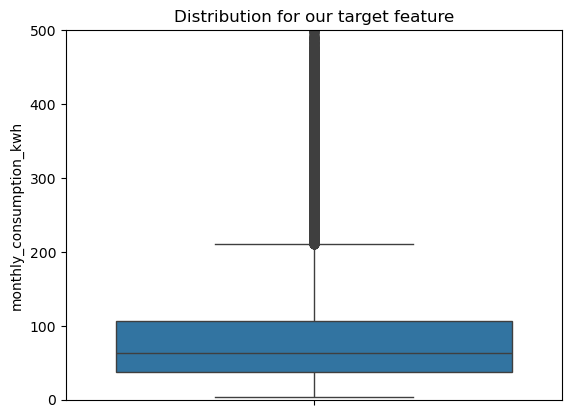

In [9]:
sns.boxplot(y = df['monthly_consumption_kwh']) #Visible outliers that may affect model quality
plt.title('Distribution for our target feature')
plt.ylim(0, 500)
plt.show()

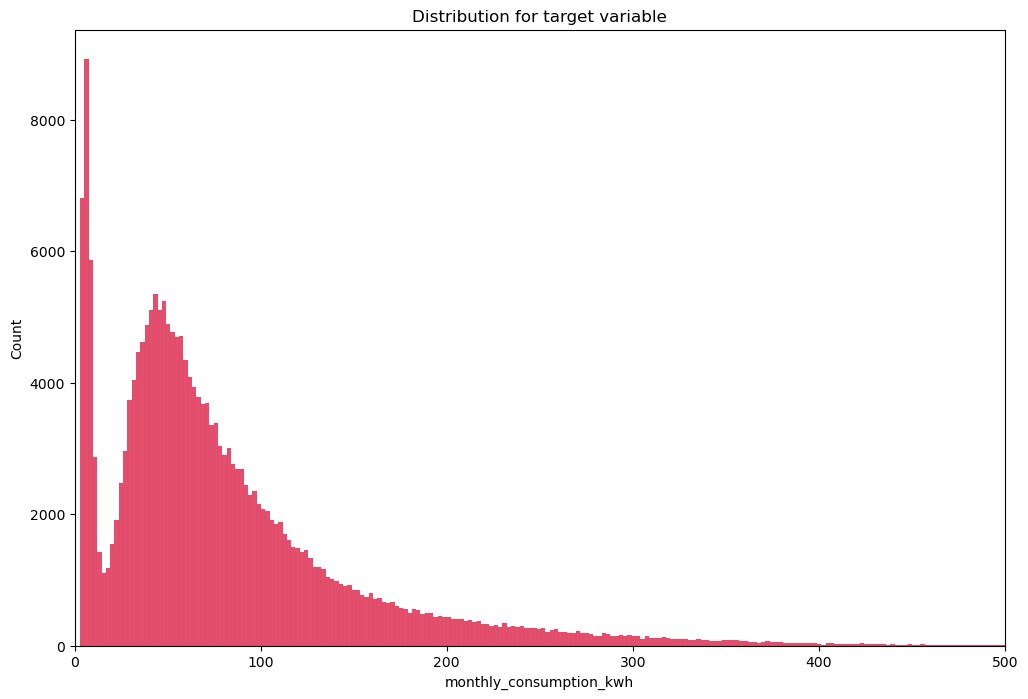

In [16]:
plt.figure(figsize = (12, 8))
sns.histplot(x = df['monthly_consumption_kwh'], color = 'crimson') #The target heavily right skewed, with huge spike toward 0
plt.xlim(0, 500)                                #Model may be weak at predicting higher energy consumptions
plt.title('Distribution for target variable')
plt.show()

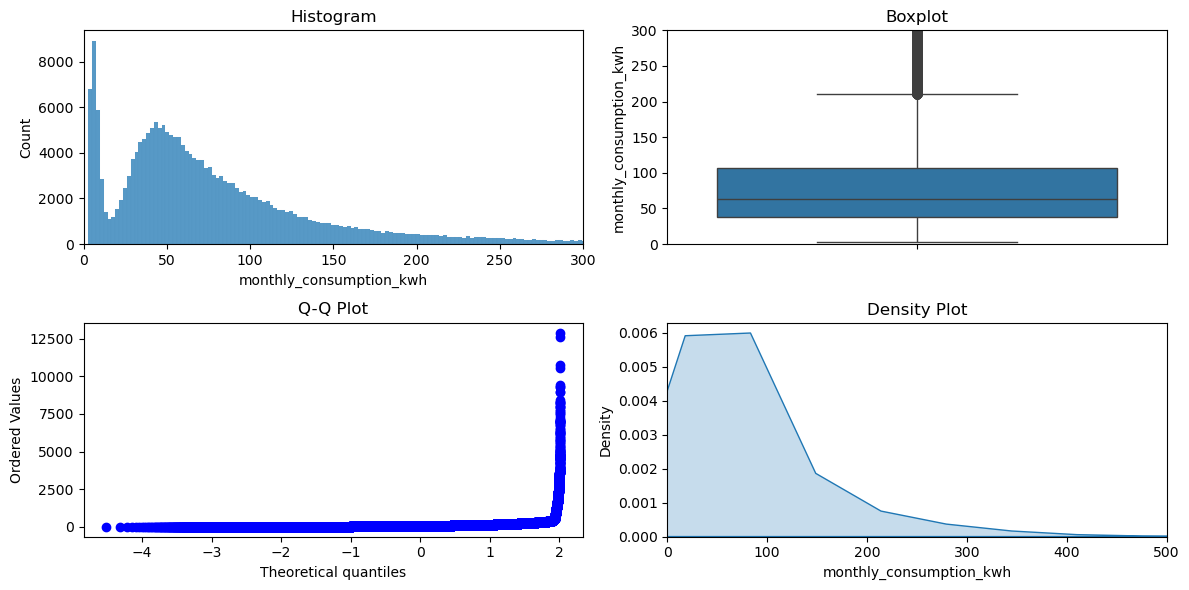

In [39]:
from scipy import stats

# Histogram
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
sns.histplot(x = df['monthly_consumption_kwh'])
plt.xlim(0, 300)
plt.title('Histogram')

# Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(y = df['monthly_consumption_kwh'])
plt.ylim(0, 300)
plt.title('Boxplot')

# Q-Q Plot
plt.subplot(2, 2, 3)
stats.probplot(df['monthly_consumption_kwh'], dist="norm", plot=plt)
plt.title('Q-Q Plot')

# Density Plot
plt.subplot(2, 2, 4)
sns.kdeplot(x =df['monthly_consumption_kwh'], fill=True)
plt.xlim(0, 500)
plt.title('Density Plot')

plt.tight_layout()
plt.show()

In [28]:
#central tendancy
mean = df['monthly_consumption_kwh'].mean()
med = df['monthly_consumption_kwh'].median()
print(f"Mean: {mean}, Median {med}")

Mean: 91.75204776091611, Median 63.2


In [ ]:
df["monthly_consumption_kwh"].isnull().sum()

np.int64(4780)

In [37]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values != 0]

income_band                5991
num_fans                   5976
monthly_consumption_kwh    4780
tariff_category            4769
avg_monthly_temp_c         4760
monthly_income_tzs         3580
num_occupants              3576
connection_age_years       3560
dwelling_type              2408
has_refrigerator           2382
region                     1783
dtype: int64

In [10]:
#Several variables contain missing values, including the target variable and predictor variables. These missing values must be handled before conducting feature engineering and machine learning analysis to ensure data quality.

In [11]:
## Missing Value Percentage

In [38]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percent
})

missing_summary = missing_summary.sort_values(
    by="Percentage",
    ascending=False
)

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
income_band,5991,2.728142
num_fans,5976,2.721311
monthly_consumption_kwh,4780,2.176685
tariff_category,4769,2.171676
avg_monthly_temp_c,4760,2.167577
monthly_income_tzs,3580,1.630237
num_occupants,3576,1.628415
connection_age_years,3560,1.621129
dwelling_type,2408,1.096539
has_refrigerator,2382,1.084699


In [47]:
#Percentage of total data with at least one missing value in its features
inc_fields = df[df.isnull().any(axis = 1)]
inc_fields


,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,num_televisions,has_air_conditioner,num_fans,has_electric_water_heater,num_lighting_points,has_electric_cooker,num_smartphones_charged,has_washing_machine,avg_monthly_temp_c,monthly_consumption_kwh
100001,TZ-HH-183857,NaN,Rural,2025,12,Cool Dry,7.0,4,Swahili House (Shared),Lower-Middle,...,2,0,0.0,0,9,0,6,0,17.3,39.7
100002,TZ-HH-117733,Dodoma,Rural,2025,3,Cool Dry,3.0,2,Swahili House (Shared),Low,...,0,0,0.0,0,2,0,3,0,21.3,5.6
100004,TZ-HH-201588,Kilimanjaro,Rural,2025,7,Long Rains,3.0,4,Swahili House (Shared),Low,...,0,0,NaN,0,3,0,4,0,21.3,3.8
100006,TZ-HH-140251,MWANZA,Peri-urban,2025,2,Hot Dry,5.0,4,Swahili House (Shared),Middle,...,2,0,0.0,0,11,0,8,0,NaN,97.7
100007,TZ-HH-171306,Dar es Salaam,Urban,2025,12,Short Rains,2.0,3,Swahili House (Shared),Lower-Middle,...,0,0,3.0,0,6,0,5,0,NaN,46.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219566,TZ-HH-116426,Dar es Salaam,Peri-urban,2024,3,Long Rains,3.0,4,Single-Family House,NaN,...,2,0,0.0,0,5,0,3,0,28.5,8.3
219571,TZ-HH-185630,Dar es Salaam,Urban,2024,7,Long Rains,3.0,4,Single-Family House,Middle,...,3,0,4.0,0,13,0,2,0,27.8,102.9
219581,TZ-HH-195670,Dar es Salaam,Urban,2024,5,Hot Dry,6.0,4,Swahili House (Shared),Middle,...,1,0,2.0,1,11,0,2,0,32.5,NaN
219586,TZ-HH-120177,Mwanza,Rural,2023,3,Cool Dry,NaN,4,Swahili House (Shared),Lower-Middle,...,1,0,0.0,0,4,0,6,0,20.8,6.4


In [57]:
#Percentage of incomplete rows
#If we delete these rows, this is how much data we lose in percentage

inc_rows = inc_fields.shape[0]
total_rows = df.shape[0]
inc_rows_percentage = int((inc_rows / total_rows) * 100)    #It's 16% of the data that has incomplete rows
print(f"Incomplete rows percent: {inc_rows_percentage}%")   #We can apply KNN Imputer to fill in missing values

Incomplete rows percent: 16%


# Analyze categorical columns

In [60]:
df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219600 entries, 0 to 219599
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   household_id               219600 non-null  object 
 1   region                     217817 non-null  object 
 2   area_type                  219600 non-null  object 
 3   year                       219600 non-null  int64  
 4   month                      219600 non-null  int64  
 5   season                     219600 non-null  object 
 6   num_occupants              216024 non-null  float64
 7   num_rooms                  219600 non-null  int64  
 8   dwelling_type              217192 non-null  object 
 9   income_band                213609 non-null  object 
 10  monthly_income_tzs         216020 non-null  float64
 11  connection_type            219600 non-null  object 
 12  meter_type                 219600 non-null  object 
 13  tariff_category            21

In [73]:
#summary of unique column items for categorical columns
df.select_dtypes(include = 'object').nunique()

household_id       215000
region                 27
area_type              12
season                  4
dwelling_type           4
income_band             5
connection_type         3
meter_type              9
tariff_category         4
dtype: int64

In [75]:
df['area_type'].value_counts() #Let's fix this, we need just 3 categories
                               #Rural, urban, and "peri-urban"

area_type
Urban         101707
Rural          57337
Peri-urban     48613
urban           2009
Urb             1930
URBAN           1910
Rur             1118
RURAL           1099
rural           1078
Periurban        974
peri-urban       926
PERI-URBAN       899
Name: count, dtype: int64

In [80]:
df['area_type'] = df['area_type'].replace(['urban', 'Urb', 'URBAN',], 'Urban')
df['area_type'] = df['area_type'].replace(['rural', 'RURAL', 'Rur',], 'Rural')
df['area_type'] = df['area_type'].replace(['Periurban', 'peri-urban', 'PERI-URBAN'], 'Peri-urban') #Cleaned!
df['area_type'].value_counts() 

area_type
Urban         107556
Rural          60632
Peri-urban     51412
Name: count, dtype: int64

In [ ]:
df['season'].value_counts() #This one looks fine

season
Cool Dry       91859
Long Rains     54277
Short Rains    36787
Hot Dry        36677
Name: count, dtype: int64

In [ ]:
df['dwelling_type'].value_counts()  #Eti swahili house 😂, and what's Single Family House?
                                    #I'll leave this as it is

dwelling_type
Swahili House (Shared)    148545
Single-Family House        34328
Apartment                  26582
Bungalow                    7737
Name: count, dtype: int64

In [89]:
df['income_band'].value_counts() #Nice!

income_band
Lower-Middle    60965
Low             60644
Middle          54337
Upper-Middle    26626
High            11037
Name: count, dtype: int64

In [90]:
df['connection_type'].value_counts()

connection_type
TANESCO Grid         173865
Solar Home System     27503
Mini-grid             18232
Name: count, dtype: int64

In [ ]:
#Another column to fix
df['meter_type'].value_counts() #Should be Simple: Prepaird, and Postpaid, But What do we do with just 'LUKU'?
                                #You cant quite assume that category is prepaid or postpaid, Im doing another check

meter_type
Prepaid (LUKU)    173947
Postpaid           31314
Prepaid-LUKU        3096
prepaid (luku)      3084
LUKU                3012
PREPAID (LUKU)      2966
Post-paid            751
POSTPAID             717
postpaid             713
Name: count, dtype: int64

In [ ]:
df['meter_type'].isna().sum()   #No nulls in this category, but we can assume LUKU is prepaid, like it is on individual homes

0

In [97]:
df['meter_type'] = df['meter_type'].replace(['Prepaid (LUKU)', 'Prepaid-LUKU', 'prepaid (luku)', 'PREPAID (LUKU)', 'LUKU'], 'Prepaid')
df['meter_type'] = df['meter_type'].replace(['Post-paid', 'POSTPAID', 'postpaid'], 'Postpaid')
df['meter_type'].value_counts()

meter_type
Prepaid     186105
Postpaid     33495
Name: count, dtype: int64

In [ ]:
df['tariff_category'].value_counts()

tariff_category
T1 (Domestic Low Usage)    102962
D1 (Lifeline)               48644
T2 (General Usage)          36297
Off-grid (SHS)              26928
Name: count, dtype: int64

In [68]:
#Recursive households
#Since the households were listed a maximum of two times
#Check by using sns.histplot(y = df['household_id'].nunique())
#Impact for this is minimal, not quite something we should care about

duplicate_h_ids = df.shape[0] - df['household_id'].nunique()
print(f"Duplicate household IDs: {duplicate_h_ids}")      

Duplicate household IDs: 4600


In [ ]:
##### I SHALL PROCEED WITH NUMERICAL COLUMNS ON NEXT SESSION

In [13]:
# Data Cleaning
## Handling Missing Values

In [15]:
for column in df.columns:

    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])

    else:
        df[column] = df[column].fillna(df[column].median())

In [18]:
df.isnull().sum()

household_id                 0
region                       0
area_type                    0
year                         0
month                        0
season                       0
num_occupants                0
num_rooms                    0
dwelling_type                0
income_band                  0
monthly_income_tzs           0
connection_type              0
meter_type                   0
tariff_category              0
connection_age_years         0
has_refrigerator             0
num_televisions              0
has_air_conditioner          0
num_fans                     0
has_electric_water_heater    0
num_lighting_points          0
has_electric_cooker          0
num_smartphones_charged      0
has_washing_machine          0
avg_monthly_temp_c           0
monthly_consumption_kwh      0
dtype: int64

In [17]:
## Duplicate Record Detection

In [19]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 4453


In [20]:
df = df.drop_duplicates()

print(df.shape)

(215147, 26)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215147 entries, 0 to 219599
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   household_id               215147 non-null  object 
 1   region                     215147 non-null  object 
 2   area_type                  215147 non-null  object 
 3   year                       215147 non-null  int64  
 4   month                      215147 non-null  int64  
 5   season                     215147 non-null  object 
 6   num_occupants              215147 non-null  float64
 7   num_rooms                  215147 non-null  int64  
 8   dwelling_type              215147 non-null  object 
 9   income_band                215147 non-null  object 
 10  monthly_income_tzs         215147 non-null  float64
 11  connection_type            215147 non-null  object 
 12  meter_type                 215147 non-null  object 
 13  tariff_category            215147 

In [22]:
## The dataset was successfully cleaned by handling missing values and removing duplicate records. The final dataset contains 215,147 complete observations with 26 variables, providing a reliable foundation for exploratory data analysis and feature engineering.

In [24]:
# Exploratory Data Analysis (EDA)

#Exploratory Data Analysis was performed to understand the distribution of variables, identify patterns, detect outliers, and examine relationships among features before feature engineering.

In [25]:
## Histograms of Numerical Variables

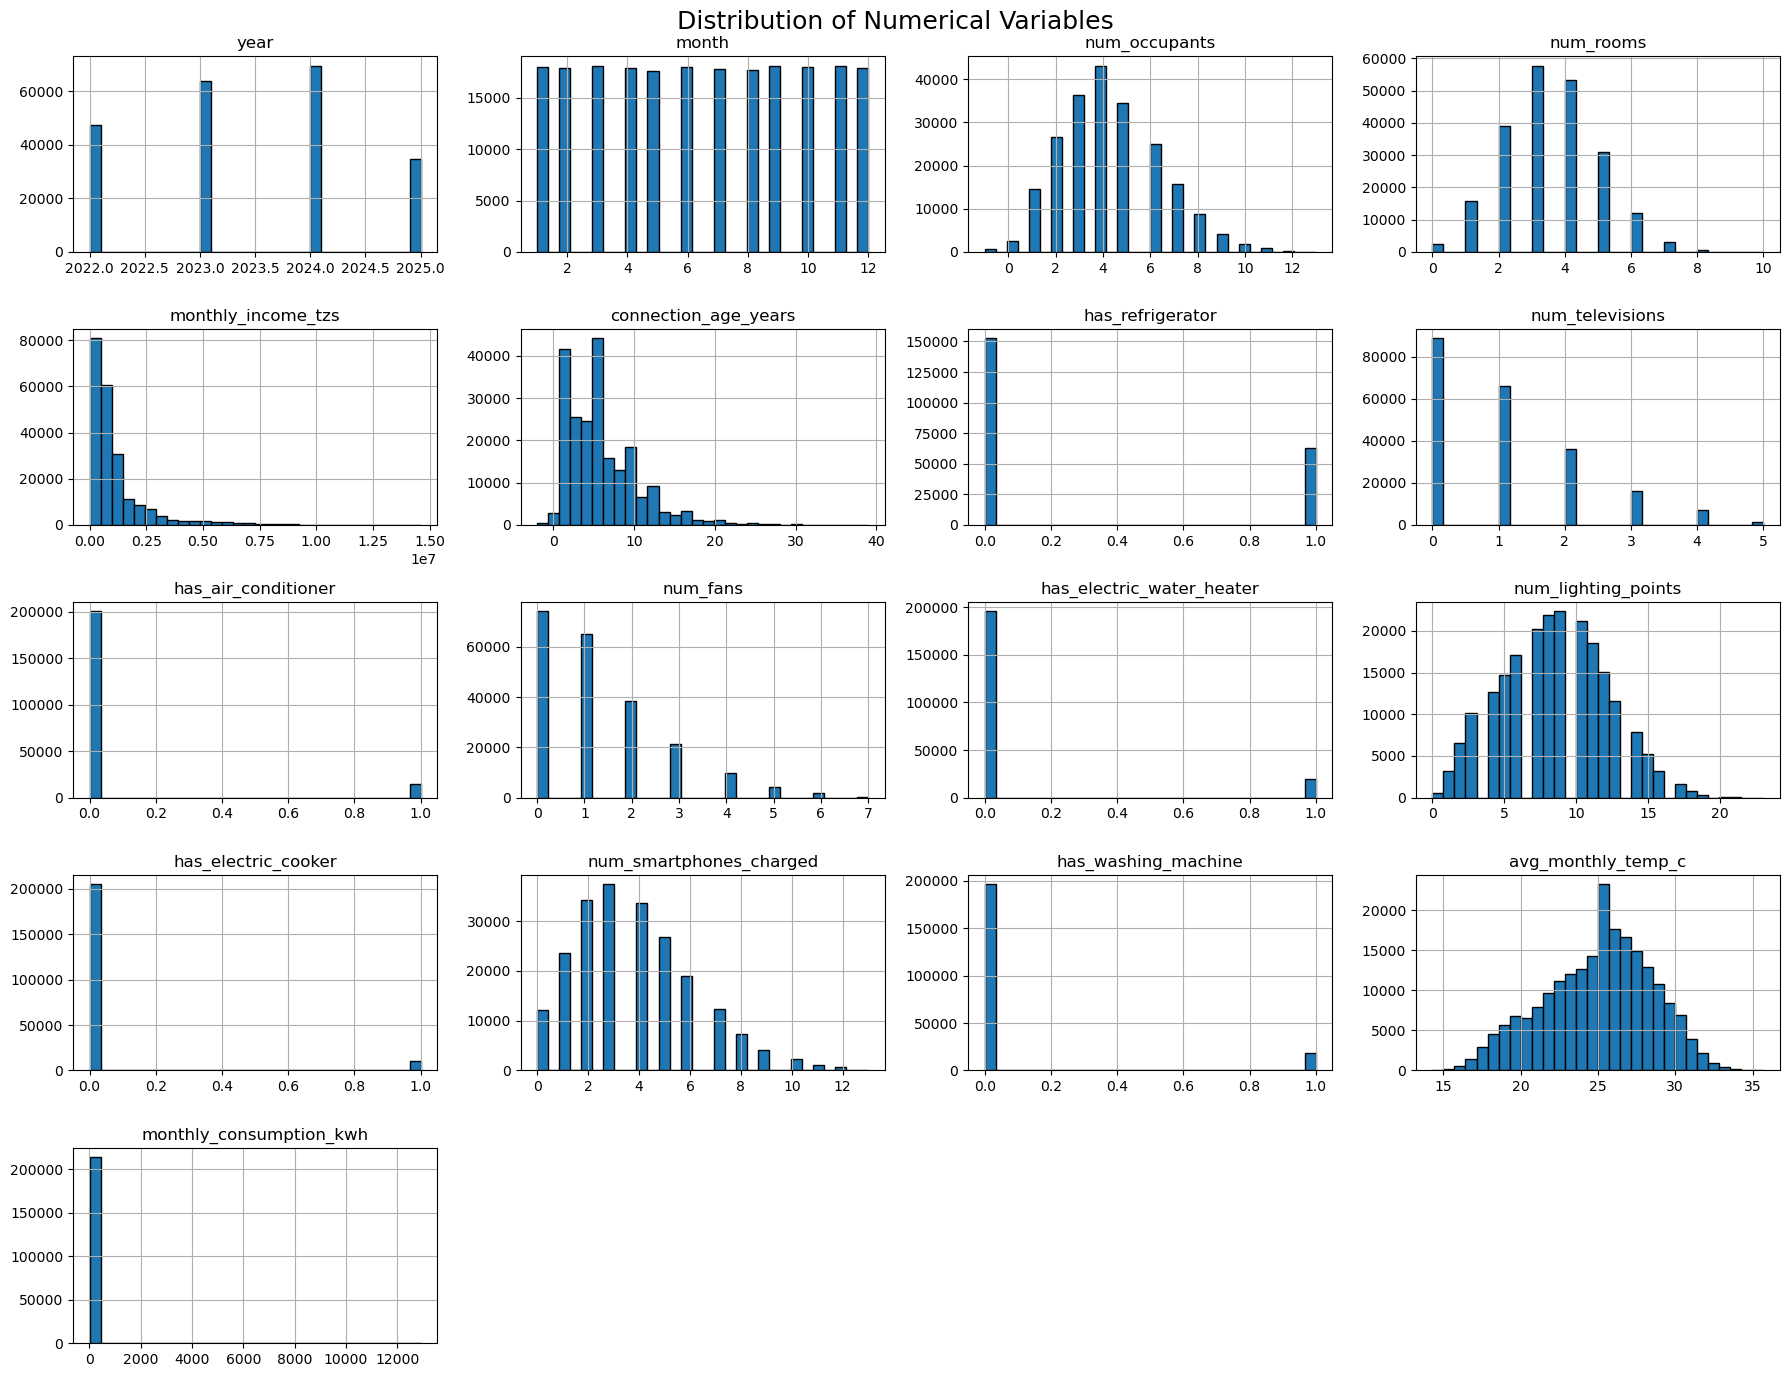

In [26]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

In [27]:
## Distribution of Monthly Electricity Consumption

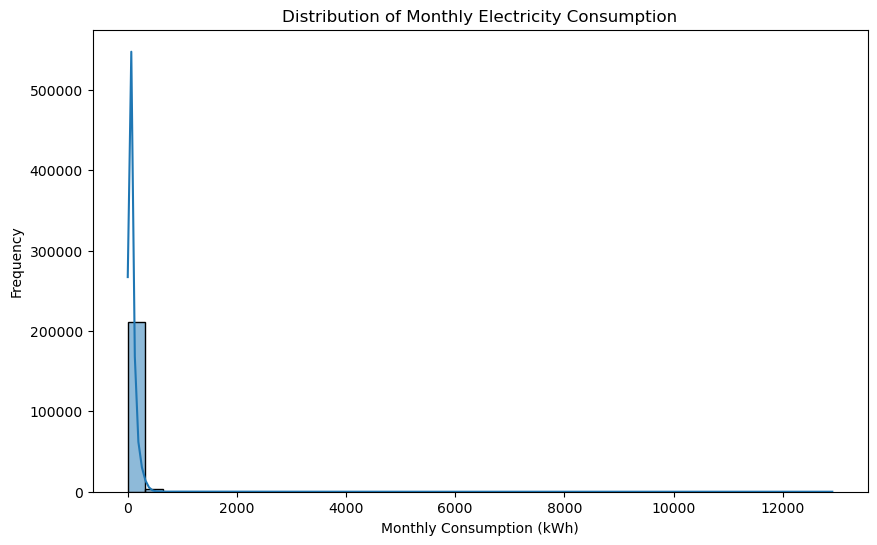

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["monthly_consumption_kwh"],
    bins=40,
    kde=True
)

plt.title("Distribution of Monthly Electricity Consumption")
plt.xlabel("Monthly Consumption (kWh)")
plt.ylabel("Frequency")

plt.show()

In [29]:
## Outlier Detection

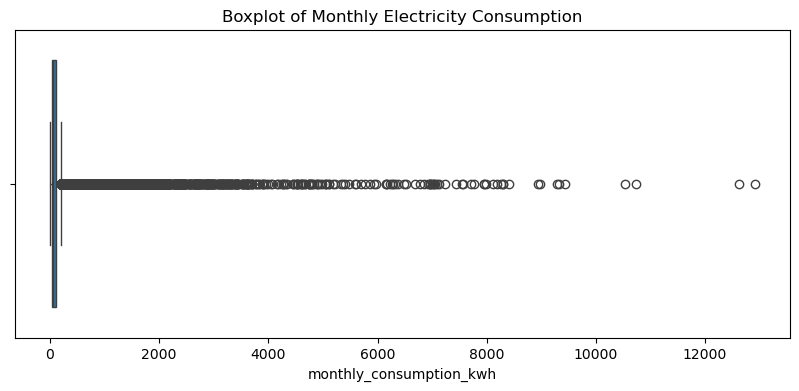

In [30]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["monthly_consumption_kwh"]
)

plt.title("Boxplot of Monthly Electricity Consumption")

plt.show()

In [31]:
## Correlation Heatmap

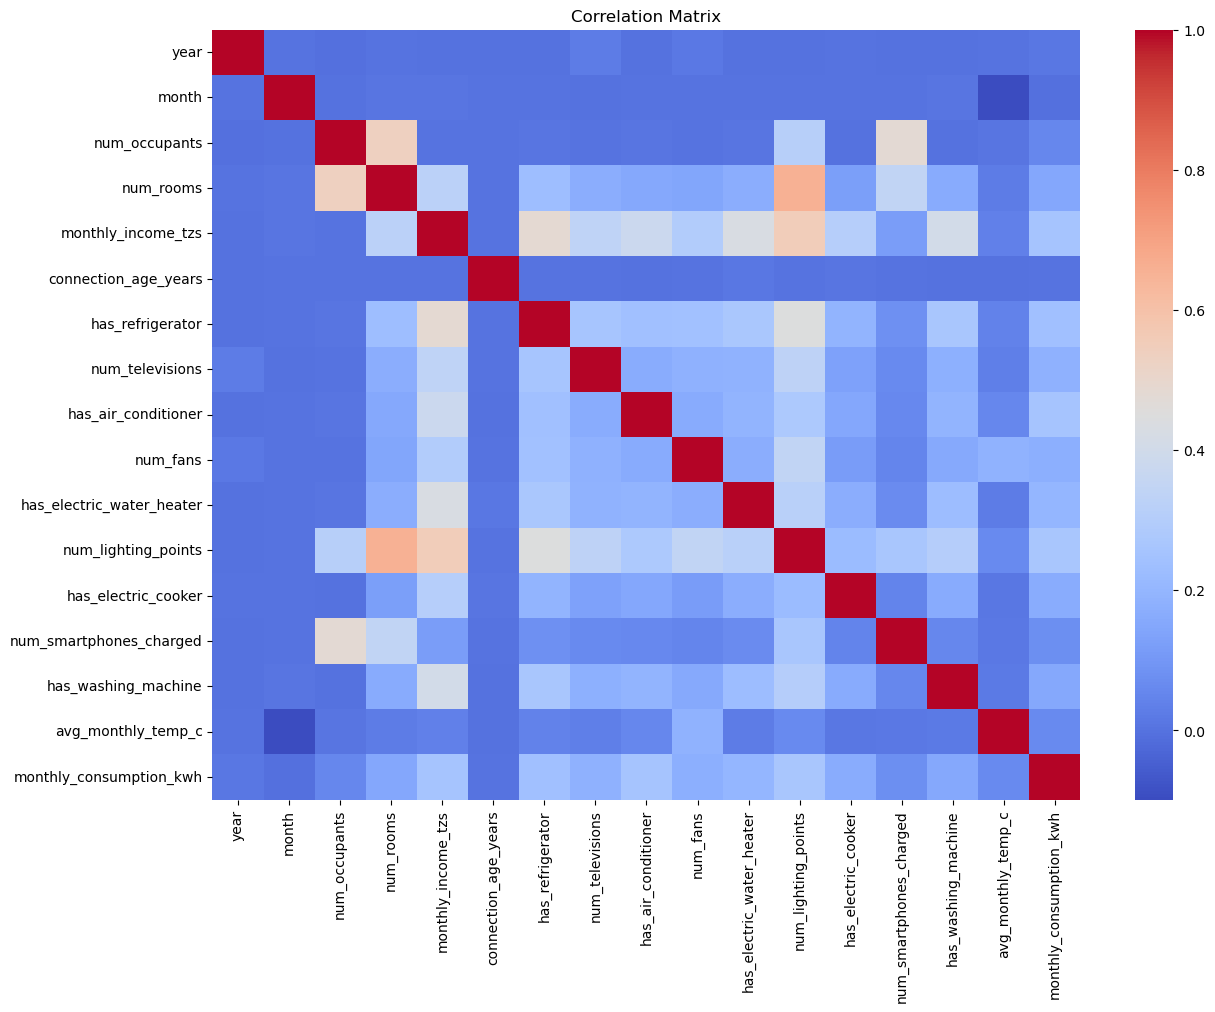

In [32]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [33]:
target_corr = correlation_matrix["monthly_consumption_kwh"].sort_values(ascending=False)

target_corr

monthly_consumption_kwh      1.000000
num_lighting_points          0.265634
has_air_conditioner          0.257215
monthly_income_tzs           0.253356
has_refrigerator             0.239396
has_electric_water_heater    0.201513
num_televisions              0.180305
num_fans                     0.173549
has_electric_cooker          0.163714
has_washing_machine          0.151907
num_rooms                    0.148462
num_smartphones_charged      0.076346
avg_monthly_temp_c           0.063428
num_occupants                0.054047
year                         0.012589
connection_age_years         0.003905
month                       -0.005756
Name: monthly_consumption_kwh, dtype: float64

In [34]:
target_corr.head(15)

monthly_consumption_kwh      1.000000
num_lighting_points          0.265634
has_air_conditioner          0.257215
monthly_income_tzs           0.253356
has_refrigerator             0.239396
has_electric_water_heater    0.201513
num_televisions              0.180305
num_fans                     0.173549
has_electric_cooker          0.163714
has_washing_machine          0.151907
num_rooms                    0.148462
num_smartphones_charged      0.076346
avg_monthly_temp_c           0.063428
num_occupants                0.054047
year                         0.012589
Name: monthly_consumption_kwh, dtype: float64

In [35]:
# Outlier Treatment

In [36]:
Q1 = df["monthly_consumption_kwh"].quantile(0.25)
Q3 = df["monthly_consumption_kwh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -63.10000000000001
Upper Bound: 206.5


In [37]:
outliers = df[
    (df["monthly_consumption_kwh"] < lower_bound) |
    (df["monthly_consumption_kwh"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 14890


In [38]:
df = df[
    (df["monthly_consumption_kwh"] >= lower_bound) &
    (df["monthly_consumption_kwh"] <= upper_bound)
]

print(df.shape)

(200257, 26)


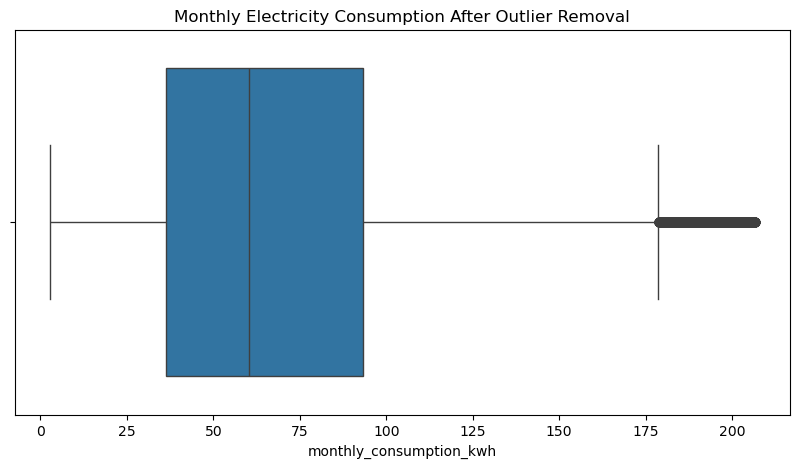

In [39]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["monthly_consumption_kwh"]
)

plt.title("Monthly Electricity Consumption After Outlier Removal")

plt.show()

In [79]:
# Feature Engineering

In [80]:
df["total_appliances"] = (
    df["has_refrigerator"] +
    df["num_televisions"] +
    df["has_air_conditioner"] +
    df["has_electric_water_heater"] +
    df["has_electric_cooker"] +
    df["has_washing_machine"]
)

In [69]:
# Appliance density
df["appliances_per_room"] = (
    df["total_appliances"] /
    df["num_rooms"].replace(0, 1)
)

# Lighting density
df["lighting_per_room"] = (
    df["num_lighting_points"] /
    df["num_rooms"].replace(0, 1)
)

# Income per person
df["income_per_person"] = (
    df["monthly_income_tzs"] /
    df["num_occupants"].replace(0, 1)
)

# Rooms per person
df["rooms_per_person"] = (
    df["num_rooms"] /
    df["num_occupants"].replace(0, 1)
)

# Appliance ownership score
df["ownership_score"] = (
    df["has_refrigerator"] +
    df["has_air_conditioner"] +
    df["has_electric_water_heater"] +
    df["has_electric_cooker"] +
    df["has_washing_machine"]
)

# Comfort appliance score
df["comfort_score"] = (
    df["has_air_conditioner"] +
    df["has_electric_water_heater"] +
    df["has_electric_cooker"]
)

# Lighting density per person
df["lighting_density"] = (
    df["num_lighting_points"] /
    df["num_occupants"].replace(0, 1)
)

In [70]:
df.head()

,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,total_appliances,consumption_per_occupant,consumption_per_room,appliances_per_room,lighting_per_room,income_per_person,rooms_per_person,ownership_score,comfort_score,lighting_density
0,0,14,5,2022,10,0,3.0,4,3,4,...,3.0,23.366667,17.525,0.75,3.25,875000.000000,1.333333,1.0,1,4.333333
1,1,2,5,2024,5,2,2.0,2,3,1,...,1.0,27.300000,27.300,0.50,2.00,74500.000000,1.000000,0.0,0,2.000000
2,2,20,8,2024,11,3,6.0,4,3,2,...,1.0,13.916667,20.875,0.25,2.50,139500.000000,0.666667,0.0,0,1.666667
3,3,18,8,2024,5,2,4.0,4,2,3,...,3.0,44.950000,44.950,0.75,2.25,237500.000000,1.000000,1.0,1,2.250000
5,4,17,5,2024,11,3,6.0,5,3,2,...,0.0,7.400000,8.880,0.00,2.00,84333.333333,0.833333,0.0,0,1.666667


In [71]:
# Remove old feature engineering columns that use the target variable
df = df.drop(
    columns=[
        "consumption_per_room",
        "consumption_per_occupant"
    ],
    errors="ignore"
)

print("Old leakage features removed successfully.")

Old leakage features removed successfully.


In [73]:
df.columns

Index(['household_id', 'region', 'area_type', 'year', 'month', 'season',
       'num_occupants', 'num_rooms', 'dwelling_type', 'income_band',
       'monthly_income_tzs', 'connection_type', 'meter_type',
       'tariff_category', 'connection_age_years', 'has_refrigerator',
       'num_televisions', 'has_air_conditioner', 'num_fans',
       'has_electric_water_heater', 'num_lighting_points',
       'has_electric_cooker', 'num_smartphones_charged', 'has_washing_machine',
       'avg_monthly_temp_c', 'monthly_consumption_kwh', 'total_appliances',
       'appliances_per_room', 'lighting_per_room', 'income_per_person',
       'rooms_per_person', 'ownership_score', 'comfort_score',
       'lighting_density'],
      dtype='object')

In [47]:
# Feature Importance Analysis

In [74]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the engineered dataset
df_encoded = df.copy()

# Encode categorical variables
label_encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(include="object").columns

for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(
        df_encoded[column].astype(str)
    )

print(df_encoded.shape)
df_encoded.head()

(200257, 34)


,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,avg_monthly_temp_c,monthly_consumption_kwh,total_appliances,appliances_per_room,lighting_per_room,income_per_person,rooms_per_person,ownership_score,comfort_score,lighting_density
0,0,14,5,2022,10,0,3.0,4,3,4,...,23.8,70.1,3.0,0.75,3.25,875000.000000,1.333333,1.0,1,4.333333
1,1,2,5,2024,5,2,2.0,2,3,1,...,21.3,54.6,1.0,0.50,2.00,74500.000000,1.000000,0.0,0,2.000000
2,2,20,8,2024,11,3,6.0,4,3,2,...,29.0,83.5,1.0,0.25,2.50,139500.000000,0.666667,0.0,0,1.666667
3,3,18,8,2024,5,2,4.0,4,2,3,...,28.3,179.8,3.0,0.75,2.25,237500.000000,1.000000,1.0,1,2.250000
5,4,17,5,2024,11,3,6.0,5,3,2,...,26.1,44.4,0.0,0.00,2.00,84333.333333,0.833333,0.0,0,1.666667


In [76]:
X = df_encoded.drop(columns=["monthly_consumption_kwh"])
y = df_encoded["monthly_consumption_kwh"]

print(X.shape)
print(y.shape)

(200257, 33)
(200257,)


In [77]:
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop(columns=["monthly_consumption_kwh"])
y = df_encoded["monthly_consumption_kwh"]

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
30,ownership_score,0.562401
11,connection_type,0.115977
18,num_fans,0.033737
6,num_occupants,0.029019
13,tariff_category,0.027310
25,total_appliances,0.025759
20,num_lighting_points,0.023423
16,num_televisions,0.023262
24,avg_monthly_temp_c,0.019292
0,household_id,0.015814


In [78]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
30,ownership_score,0.562401
11,connection_type,0.115977
18,num_fans,0.033737
6,num_occupants,0.029019
13,tariff_category,0.027310
25,total_appliances,0.025759
20,num_lighting_points,0.023423
16,num_televisions,0.023262
24,avg_monthly_temp_c,0.019292
0,household_id,0.015814


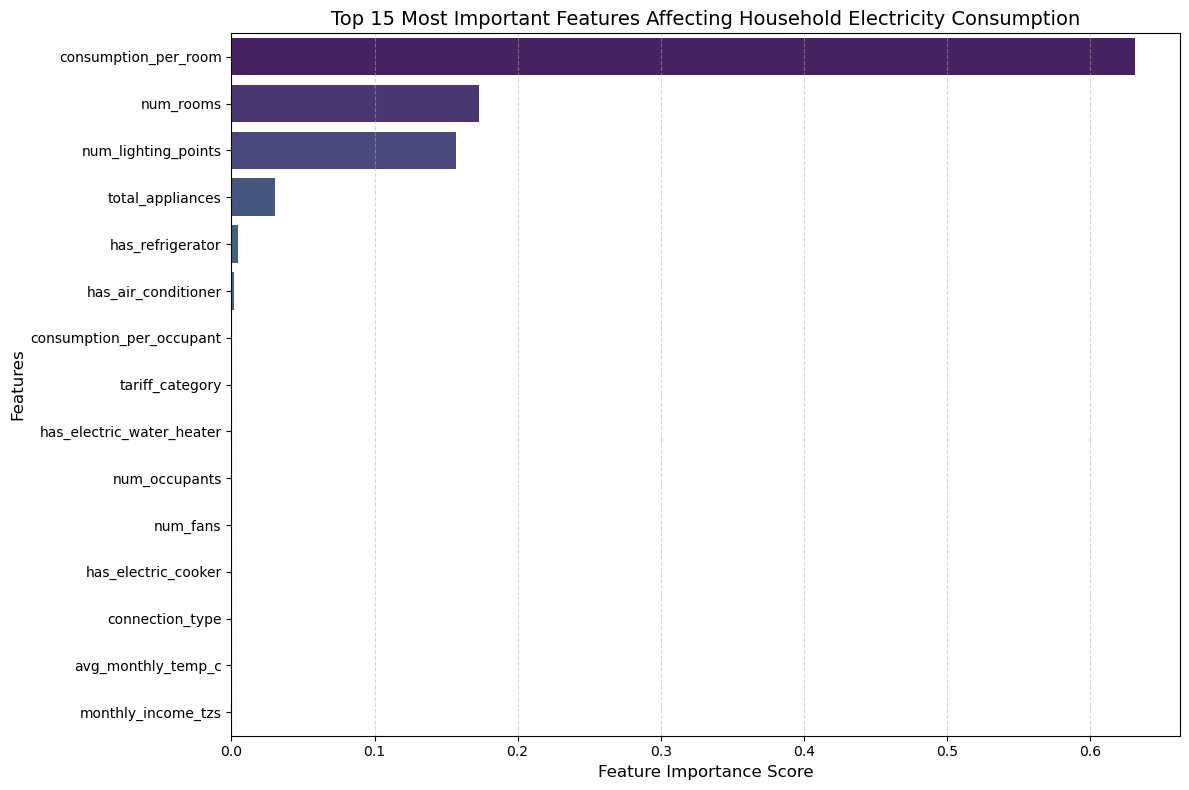

In [56]:
plt.figure(figsize=(12,8))

top_features = feature_importance.head(15)

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 15 Most Important Features Affecting Household Electricity Consumption", fontsize=14)
plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [75]:
df.to_csv(
    "electricity_consumption_processed_60_percent.csv",
    index=False
)